In [1]:
import numpy as np
import pandas as pd

In [2]:
data = pd.read_csv("spam.csv",encoding='latin-1')

In [3]:
data

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [5]:
data.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [6]:
data = data[['v1','v2']].copy()
data.columns = ['label','message']

In [7]:
data['label'] = data['label'].map({'ham':0,'spam':1})

In [8]:
data


,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='label', ylabel='count'>

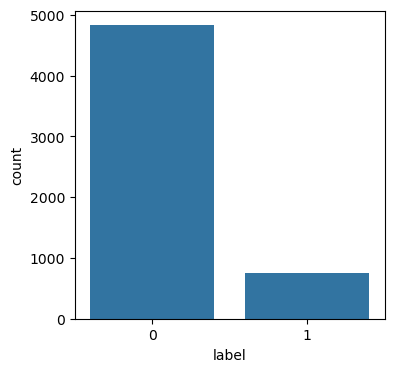

In [10]:
plt.figure(figsize=(4,4))
sns.countplot(x = "label",data=data)

In [11]:
spam = data[data['label'] == 1]
ham = data[data['label'] == 0]

spam_upsampled = spam.sample(n=len(ham), replace=True, random_state=42)

data_balanced = pd.concat([ham, spam_upsampled])

data_balanced = data_balanced.sample(frac=1, random_state=42)

data_balanced.head()

,label,message
4365,0,Mm yes dear look how i am hugging you both. :-P
4685,0,But pls dont play in others life.
4812,0,i can call in &lt;#&gt; min if thats ok
3948,0,HMM yeah if your not too grooved out! And im l...
5449,1,"Latest News! Police station toilet stolen, cop..."


<Axes: xlabel='label', ylabel='count'>

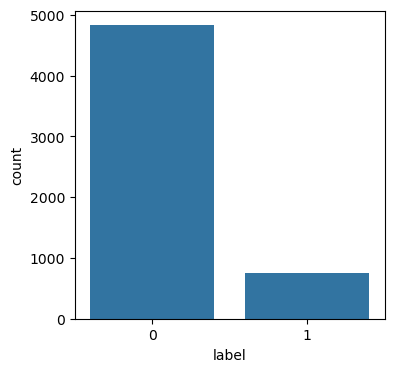

In [12]:
plt.figure(figsize=(4,4))
sns.countplot(x = "label",data=data)

<Axes: xlabel='word_count', ylabel='Count'>

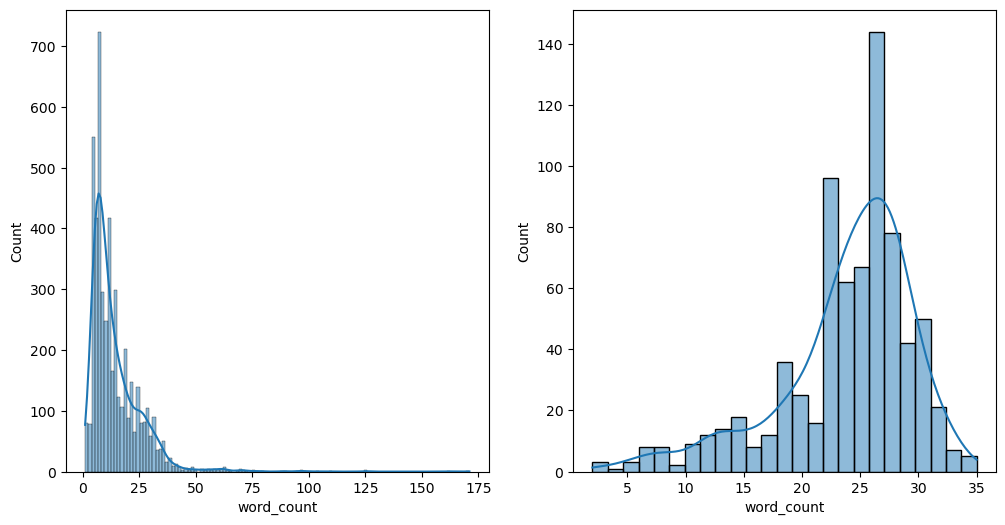

In [13]:
data['word_count'] = data['message'].apply(lambda x: len(x.split()))
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
sns.histplot(data[data['label'] == 0].word_count, kde = True)

plt.subplot(1,2,2)
sns.histplot(data[data['label'] == 1].word_count, kde = True)

In [14]:
def currency(data):
    curr_sym = ['$','€','£','¥','₹']
    for i in curr_sym:
        if i in data:
            return 1
        return 0

In [17]:
data['cur_sym'] = data['message'].apply(currency)

In [18]:
data

,label,message,word_count,cur_sym
0,0,"Go until jurong point, crazy.. Available only ...",20,0
1,0,Ok lar... Joking wif u oni...,6,0
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,28,0
3,0,U dun say so early hor... U c already then say...,11,0
4,0,"Nah I don't think he goes to usf, he lives aro...",13,0
...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,30,0
5568,0,Will Ì_ b going to esplanade fr home?,8,0
5569,0,"Pity, * was in mood for that. So...any other s...",10,0
5570,0,The guy did some bitching but I acted like i'd...,26,0


<Axes: xlabel='cur_sym', ylabel='count'>

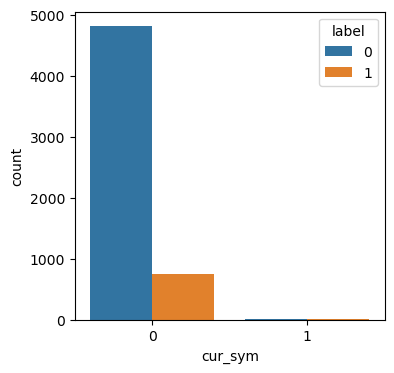

In [19]:
plt.figure(figsize=(4,4))
sns.countplot(x = "cur_sym",data=data, hue = 'label')

In [22]:
def num(data):
    for i in data:
        if ord(i) >= 48 and ord(i) <= 57:
            return 1
        return 0

In [23]:
data['has_num'] = data['message'].apply(num)

In [24]:
data

,label,message,word_count,cur_sym,has_num
0,0,"Go until jurong point, crazy.. Available only ...",20,0,0
1,0,Ok lar... Joking wif u oni...,6,0,0
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,28,0,0
3,0,U dun say so early hor... U c already then say...,11,0,0
4,0,"Nah I don't think he goes to usf, he lives aro...",13,0,0
...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,30,0,0
5568,0,Will Ì_ b going to esplanade fr home?,8,0,0
5569,0,"Pity, * was in mood for that. So...any other s...",10,0,0
5570,0,The guy did some bitching but I acted like i'd...,26,0,0


<Axes: xlabel='has_num', ylabel='count'>

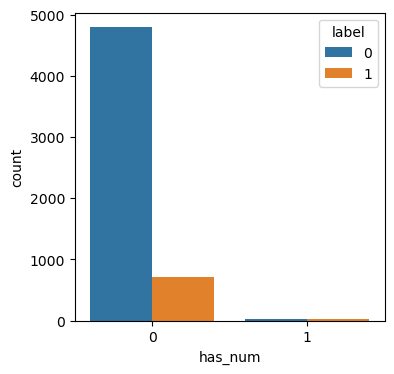

In [25]:
plt.figure(figsize=(4,4))
sns.countplot(x = "has_num",data=data, hue = 'label')

In [28]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Shayank\AppData\Roaming\nltk_data...


True

In [31]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [44]:
corpus = []
wnl = WordNetLemmatizer()

for sms in list(data.message):
    message = re.sub(pattern='[^a-zA-Z]',repl = '',string = sms)
    message = message.lower()
    message = [word for word in message.split() if word not in set(stopwords.words('english'))]
    message = [wnl.lemmatize(word) for word in message]
    message = [' '.join(message)]
    corpus.append(message)
    corpus = [' '.join(text) if isinstance(text, list) else text for text in corpus]

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=500)
vectors = tfidf.fit_transform(corpus).toarray()
features = tfidf.get_feature_names_out()

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [49]:
x = pd.DataFrame(vectors, columns=features)
y = data['label']

In [50]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [51]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

In [53]:
model1 = SVC()
model1.fit(x_train, y_train)
y_pred = model1.predict(x_test)
print(classification_report(y_test, y_pred))

model2 = SVC()
model2.fit(x_train, y_train)
y_pred = model1.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96       976
           1       1.00      0.37      0.54       139

    accuracy                           0.92      1115
   macro avg       0.96      0.69      0.75      1115
weighted avg       0.93      0.92      0.91      1115

              precision    recall  f1-score   support

           0       0.92      1.00      0.96       976
           1       1.00      0.37      0.54       139

    accuracy                           0.92      1115
   macro avg       0.96      0.69      0.75      1115
weighted avg       0.93      0.92      0.91      1115



In [58]:
from sklearn.naive_bayes import MultinomialNB
mnb = MultinomialNB()
mnb.fit(x_train, y_train)
y_pred2 = mnb.predict(x_test)
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       0.88      1.00      0.93       976
           1       1.00      0.02      0.04       139

    accuracy                           0.88      1115
   macro avg       0.94      0.51      0.49      1115
weighted avg       0.89      0.88      0.82      1115



In [69]:
from sklearn.metrics import confusion_matrix

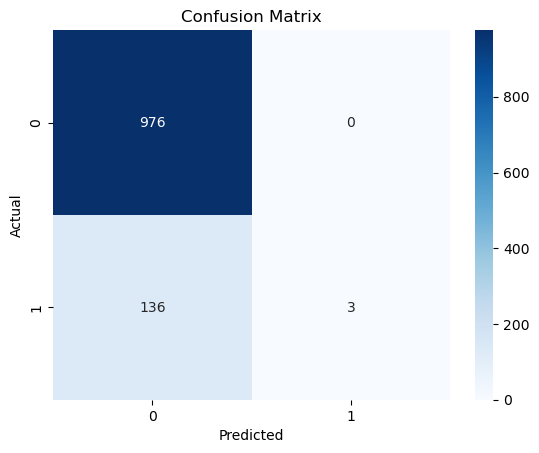

In [70]:
cm = confusion_matrix(y_test, y_pred2)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()